# Visualization — Heatmaps, Box Plots & Time Series

Tổng hợp biểu đồ trọng tâm từ EDA Stage 1 (Cancellation) và Stage 2 (ADR):
- **Heatmaps**
- **Box plots**
- **Time series** (cancellation rate & ADR theo timeline tháng/năm)

In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_MAP = {name: idx + 1 for idx, name in enumerate(MONTH_ORDER)}
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]
CUSTOMER_TYPE_ORDER = ["Transient", "Transient-Party", "Contract", "Group"]
CHANNEL_ORDER = ["Direct", "Corporate", "TA/TO", "GDS"]


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent
    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file(min_version: int = 5) -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match and int(match.group(1)) >= min_version:
                candidates.append((int(match.group(1)), file_path.resolve()))
    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy {DATA_BASENAME}_v{min_version}+.csv")
    _, latest_path = max(candidates, key=lambda x: x[0])
    return latest_path


def add_year_month(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["year_month"] = pd.to_datetime(
        df["arrival_date_year"].astype(str)
        + "-"
        + df["arrival_date_month"].map(MONTH_MAP).astype(str).str.zfill(2)
        + "-01"
    )
    return df


csv_path = find_latest_versioned_data_file(min_version=5)
print(f"Đang đọc: {csv_path}")
df = pd.read_csv(csv_path)
df = add_year_month(df)

df_adr = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()
df_adr["arrival_date_month"] = pd.Categorical(
    df_adr["arrival_date_month"], categories=MONTH_ORDER, ordered=True
)
if "day_of_week" in df_adr.columns:
    df_adr["day_of_week"] = pd.Categorical(
        df_adr["day_of_week"], categories=DAY_ORDER, ordered=True
    )
df_adr["room_match"] = (
    df_adr["reserved_room_type"] == df_adr["assigned_room_type"]
)

df["cancel_status"] = df["is_canceled"].map(
    {0: "Không hủy (0)", 1: "Đã hủy (1)"}
)

print(f"Tổng booking: {len(df):,}")
print(f"Booking ADR analysis: {len(df_adr):,}")
print(f"Timeline: {df['year_month'].min():%Y-%m} → {df['year_month'].max():%Y-%m}")

Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv


Tổng booking: 82,811
Booking ADR analysis: 58,066
Timeline: 2015-07 → 2017-08


## 1. Heatmaps

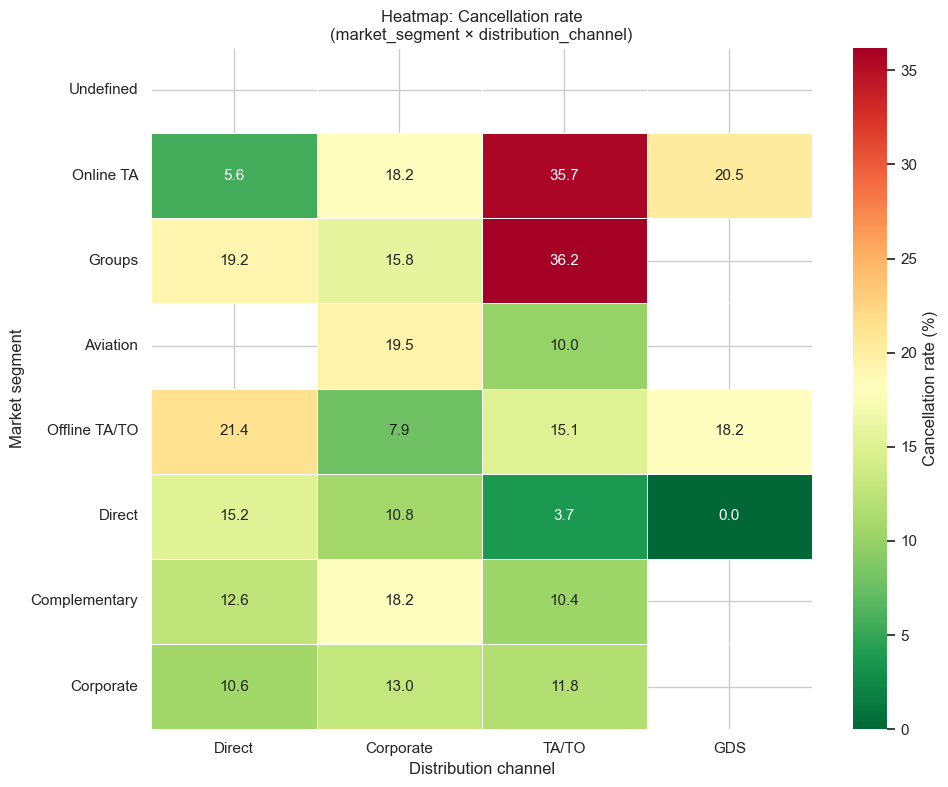

In [2]:
# Heatmap 1: cancellation_rate — market_segment × distribution_channel
segment_order = (
    df.groupby("market_segment", observed=True)["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    .index
)
heat_cancel = (
    df.groupby(["market_segment", "distribution_channel"], observed=True)["is_canceled"]
    .mean()
    .mul(100)
    .unstack(fill_value=np.nan)
    .reindex(index=segment_order, columns=CHANNEL_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heat_cancel,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Cancellation rate (%)"},
    ax=ax,
)
ax.set_title("Heatmap: Cancellation rate\n(market_segment × distribution_channel)")
ax.set_xlabel("Distribution channel")
ax.set_ylabel("Market segment")
plt.tight_layout()
plt.show()

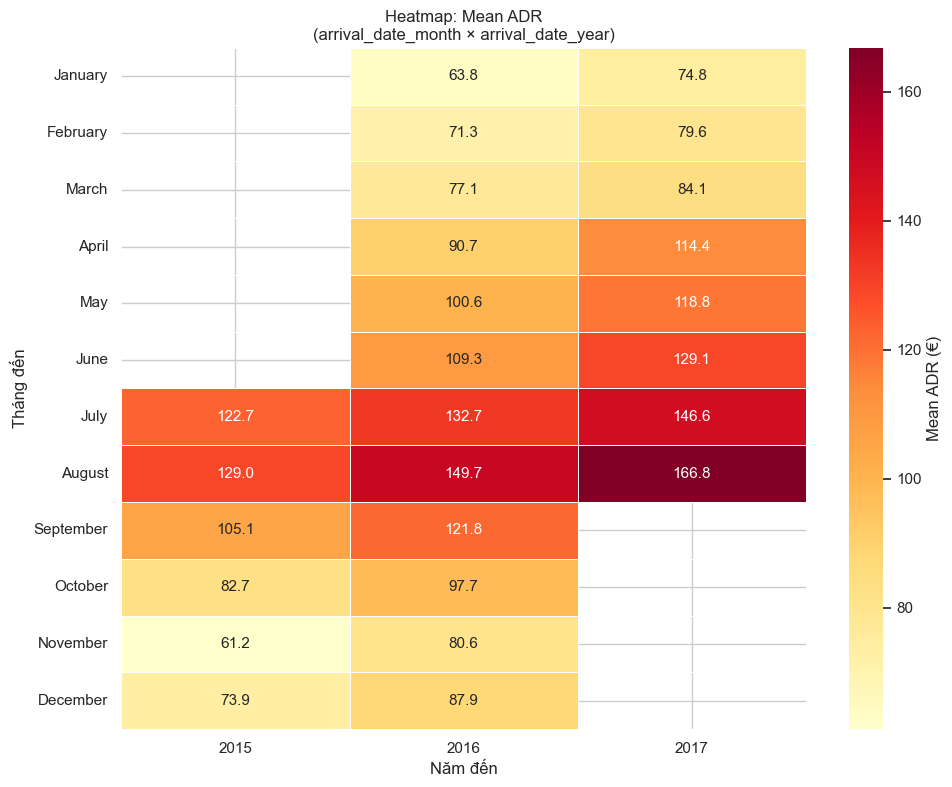

In [3]:
# Heatmap 2: mean ADR — arrival_date_month × arrival_date_year
heat_adr_month_year = (
    df_adr.groupby(["arrival_date_month", "arrival_date_year"], observed=True)["adr"]
    .mean()
    .unstack("arrival_date_year")
    .reindex(MONTH_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heat_adr_month_year,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean ADR (€)"},
    ax=ax,
)
ax.set_title("Heatmap: Mean ADR\n(arrival_date_month × arrival_date_year)")
ax.set_xlabel("Năm đến")
ax.set_ylabel("Tháng đến")
plt.tight_layout()
plt.show()

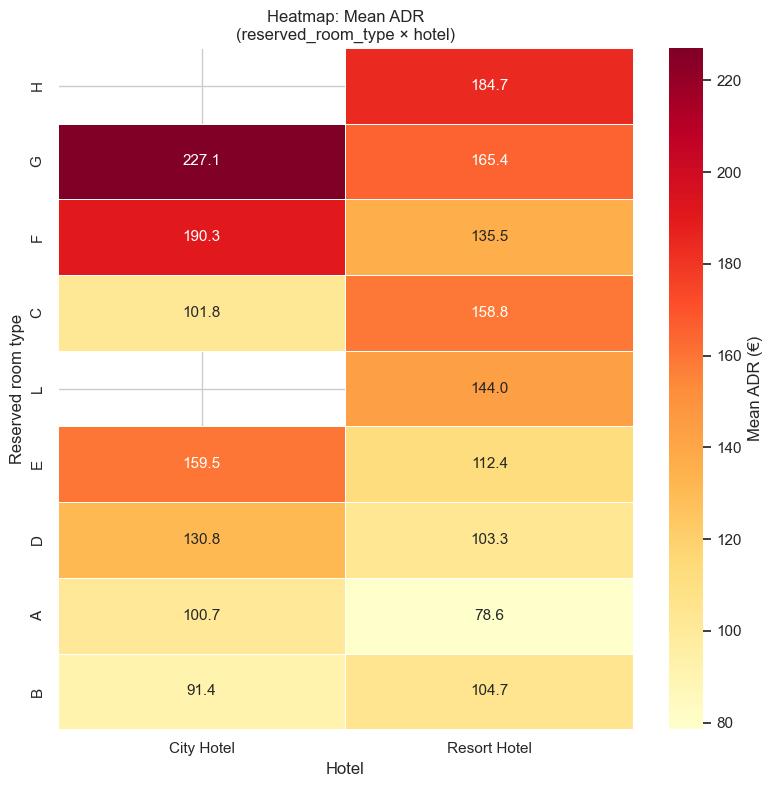

In [4]:
# Heatmap 3: mean ADR — reserved_room_type × hotel
row_order = (
    df_adr.groupby("reserved_room_type", observed=True)["adr"]
    .mean()
    .sort_values(ascending=False)
    .index
)
heat_adr_room_hotel = (
    df_adr.groupby(["reserved_room_type", "hotel"], observed=True)["adr"]
    .mean()
    .unstack("hotel")
    .reindex(row_order)
)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    heat_adr_room_hotel,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean ADR (€)"},
    ax=ax,
)
ax.set_title("Heatmap: Mean ADR\n(reserved_room_type × hotel)")
ax.set_xlabel("Hotel")
ax.set_ylabel("Reserved room type")
plt.tight_layout()
plt.show()

## 2. Box plots

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11172\473875857.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


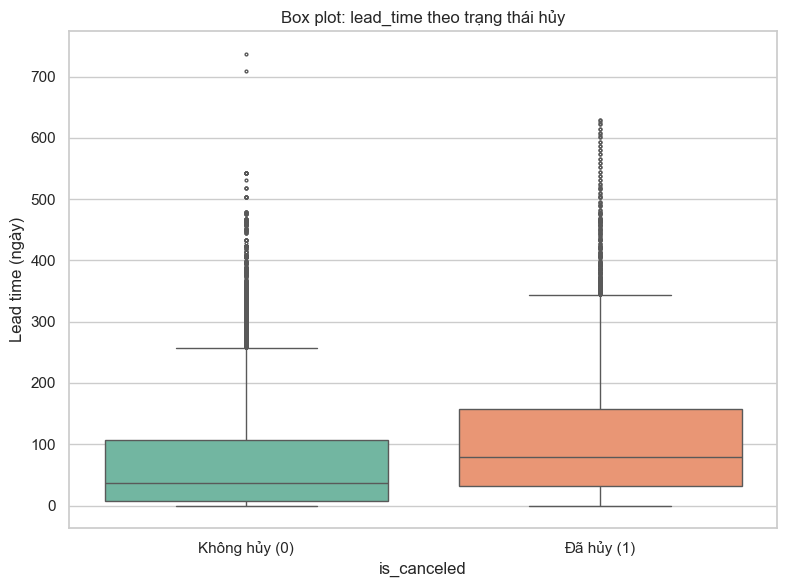

In [5]:
# Box plot 1: lead_time theo is_canceled (Stage 1)
palette = {"Không hủy (0)": "#66c2a5", "Đã hủy (1)": "#fc8d62"}
order_cancel = ["Không hủy (0)", "Đã hủy (1)"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="cancel_status",
    y="lead_time",
    order=order_cancel,
    palette=palette,
    ax=ax,
    fliersize=2,
    linewidth=1,
)
ax.set_title("Box plot: lead_time theo trạng thái hủy")
ax.set_xlabel("is_canceled")
ax.set_ylabel("Lead time (ngày)")
plt.tight_layout()
plt.show()

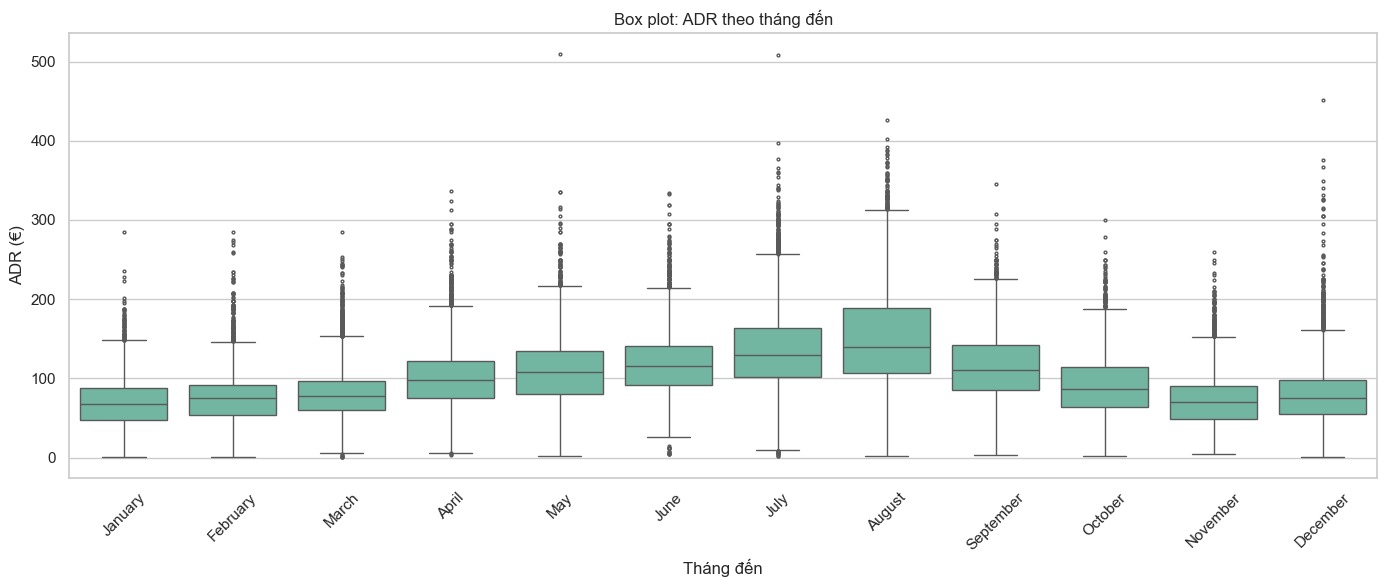

In [6]:
# Box plot 2: ADR theo arrival_date_month
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_adr,
    x="arrival_date_month",
    y="adr",
    order=MONTH_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)
ax.set_title("Box plot: ADR theo tháng đến")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("ADR (€)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

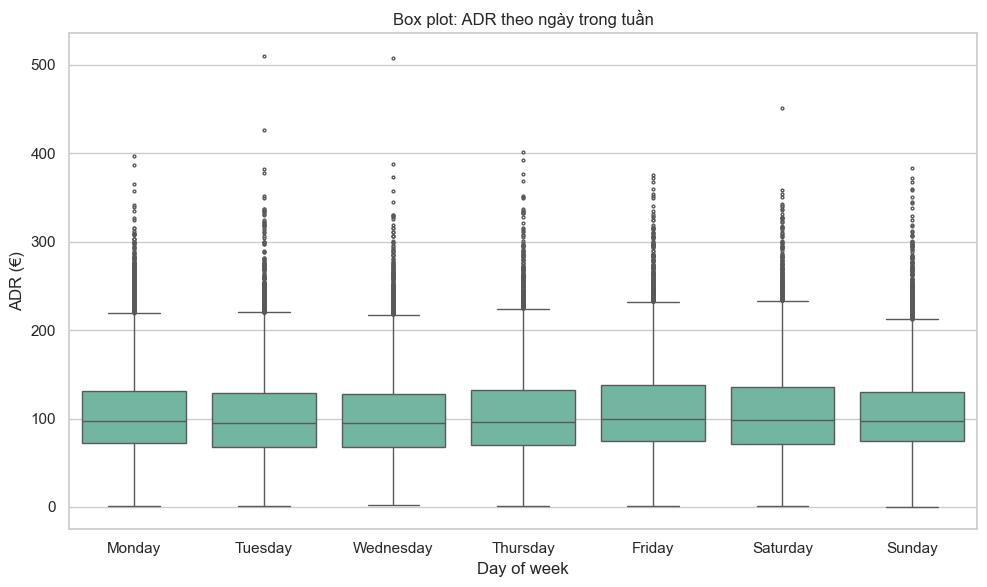

In [7]:
# Box plot 3: ADR theo day_of_week
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_adr,
    x="day_of_week",
    y="adr",
    order=DAY_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)
ax.set_title("Box plot: ADR theo ngày trong tuần")
ax.set_xlabel("Day of week")
ax.set_ylabel("ADR (€)")
plt.tight_layout()
plt.show()

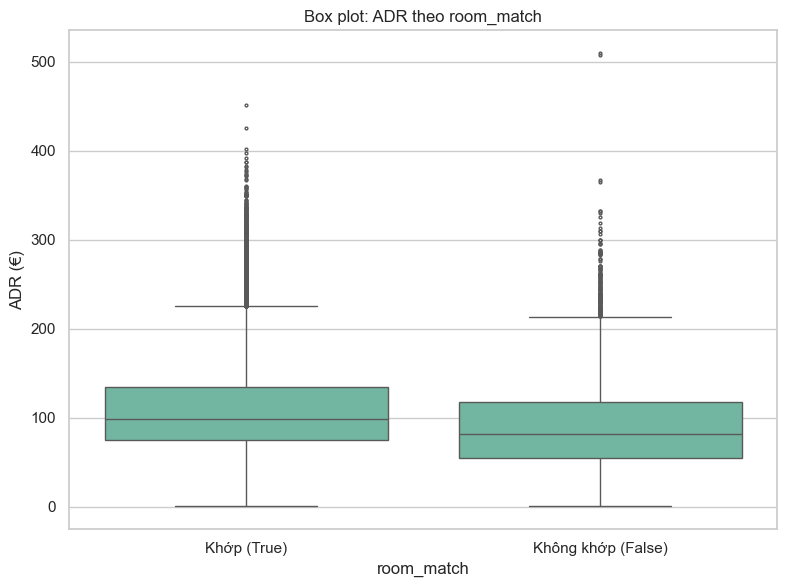

In [8]:
# Box plot 4: ADR theo room_match
df_adr["room_match_label"] = df_adr["room_match"].map(
    {True: "Khớp (True)", False: "Không khớp (False)"}
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=df_adr,
    x="room_match_label",
    y="adr",
    order=["Khớp (True)", "Không khớp (False)"],
    ax=ax,
    fliersize=2,
    linewidth=1,
)
ax.set_title("Box plot: ADR theo room_match")
ax.set_xlabel("room_match")
ax.set_ylabel("ADR (€)")
plt.tight_layout()
plt.show()

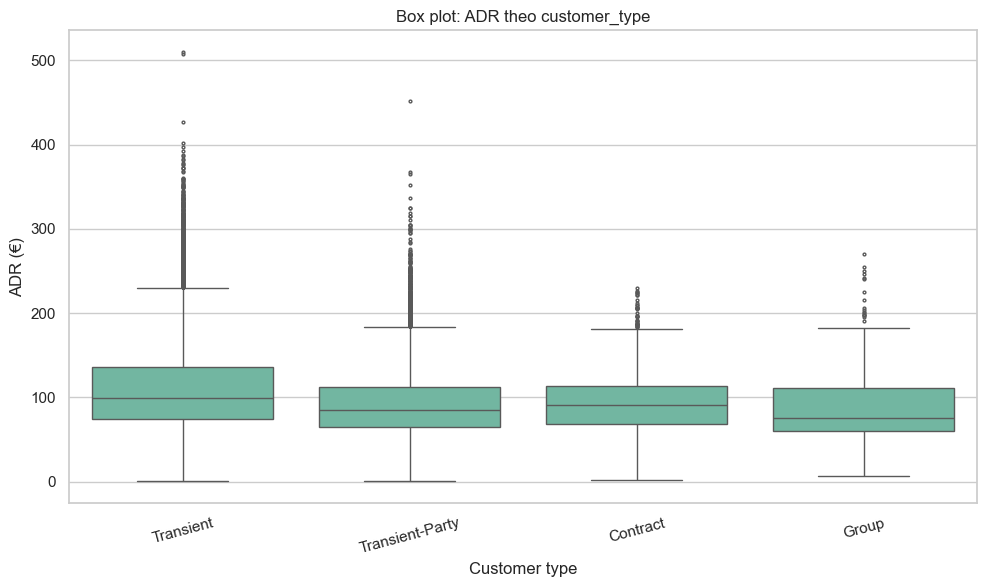

In [9]:
# Box plot 5: ADR theo customer_type
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_adr,
    x="customer_type",
    y="adr",
    order=CUSTOMER_TYPE_ORDER,
    ax=ax,
    fliersize=2,
    linewidth=1,
)
ax.set_title("Box plot: ADR theo customer_type")
ax.set_xlabel("Customer type")
ax.set_ylabel("ADR (€)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 3. Time series (timeline tháng/năm)

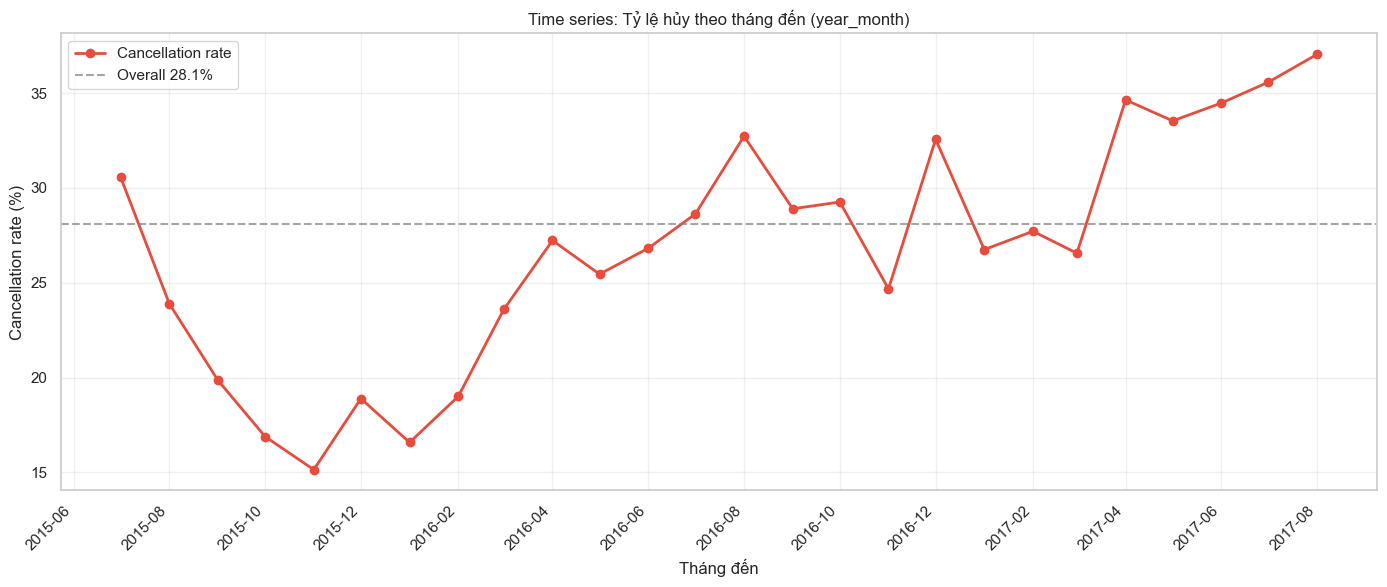

            cancellation_rate  bookings
year_month                             
2017-03-01              26.56      3483
2017-04-01              34.65      3937
2017-05-01              33.54      4347
2017-06-01              34.48      4095
2017-07-01              35.59      4423
2017-08-01              37.05      4275


In [10]:
# Time series 1: cancellation_rate theo year_month
cancel_ts = (
    df.groupby("year_month", observed=True)["is_canceled"]
    .agg(cancellation_rate=lambda x: x.mean() * 100, bookings="count")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    cancel_ts.index,
    cancel_ts["cancellation_rate"],
    marker="o",
    linewidth=2,
    color="#e74c3c",
    label="Cancellation rate",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Time series: Tỷ lệ hủy theo tháng đến (year_month)")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("Cancellation rate (%)")
ax.legend()
ax.grid(True, alpha=0.3)

overall = df["is_canceled"].mean() * 100
ax.axhline(overall, color="gray", linestyle="--", alpha=0.7, label=f"Overall {overall:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

print(cancel_ts.round(2).tail(6))

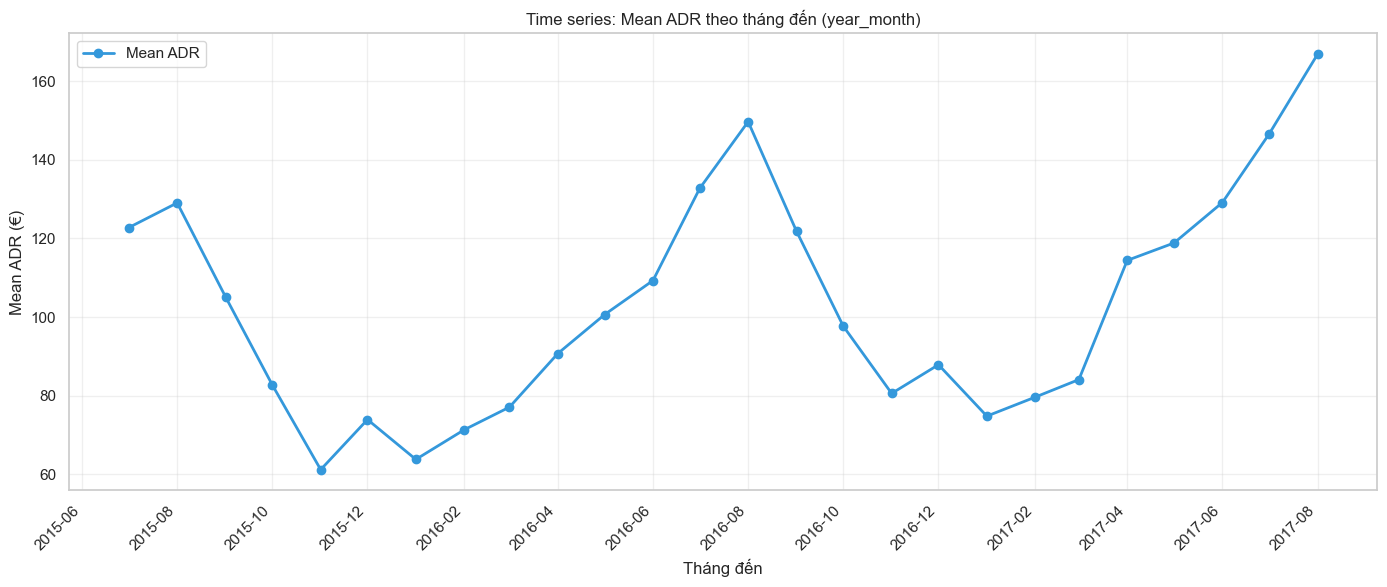

            mean_adr  bookings
year_month                    
2017-03-01     84.09      2500
2017-04-01    114.40      2537
2017-05-01    118.82      2844
2017-06-01    129.11      2642
2017-07-01    146.56      2815
2017-08-01    166.80      2666


In [11]:
# Time series 2: mean ADR theo year_month (booking không hủy, adr > 0)
adr_ts = (
    df_adr.groupby("year_month", observed=True)["adr"]
    .agg(mean_adr="mean", bookings="count")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    adr_ts.index,
    adr_ts["mean_adr"],
    marker="o",
    linewidth=2,
    color="#3498db",
    label="Mean ADR",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Time series: Mean ADR theo tháng đến (year_month)")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("Mean ADR (€)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(adr_ts.round(2).tail(6))

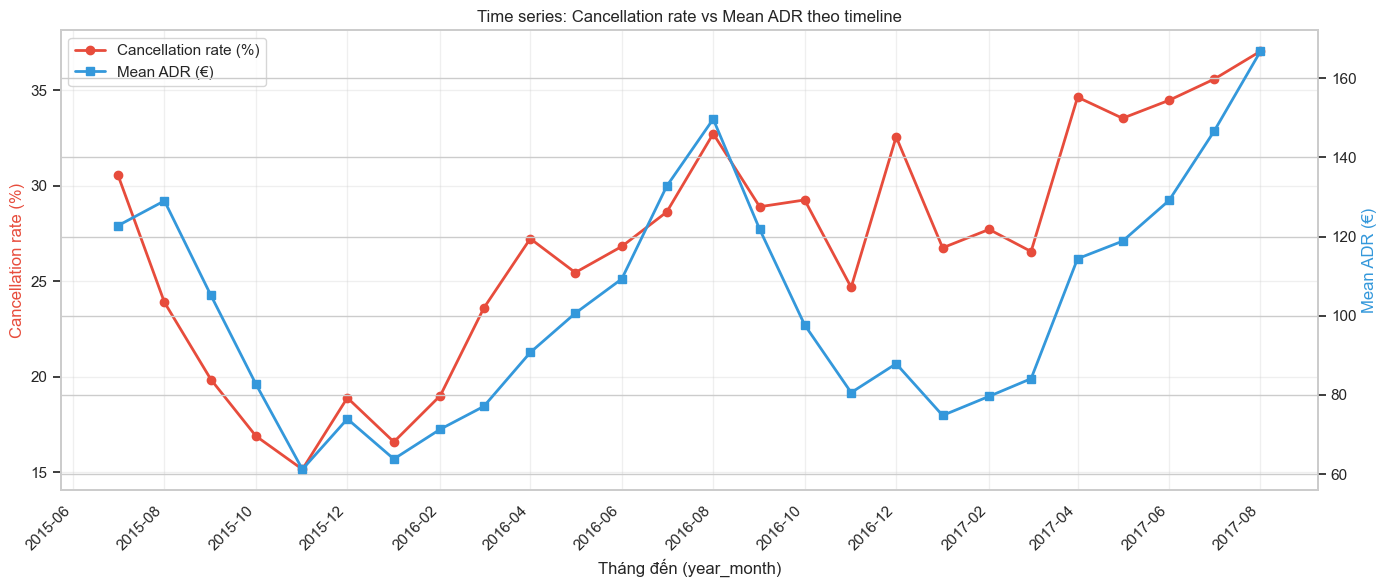

In [12]:
# Time series 3: Dual-axis — cancellation_rate & mean ADR trên cùng timeline
ts = cancel_ts[["cancellation_rate"]].join(adr_ts[["mean_adr"]], how="outer").sort_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

line1 = ax1.plot(
    ts.index,
    ts["cancellation_rate"],
    marker="o",
    linewidth=2,
    color="#e74c3c",
    label="Cancellation rate (%)",
)
line2 = ax2.plot(
    ts.index,
    ts["mean_adr"],
    marker="s",
    linewidth=2,
    color="#3498db",
    label="Mean ADR (€)",
)

ax1.set_xlabel("Tháng đến (year_month)")
ax1.set_ylabel("Cancellation rate (%)", color="#e74c3c")
ax2.set_ylabel("Mean ADR (€)", color="#3498db")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Time series: Cancellation rate vs Mean ADR theo timeline")

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

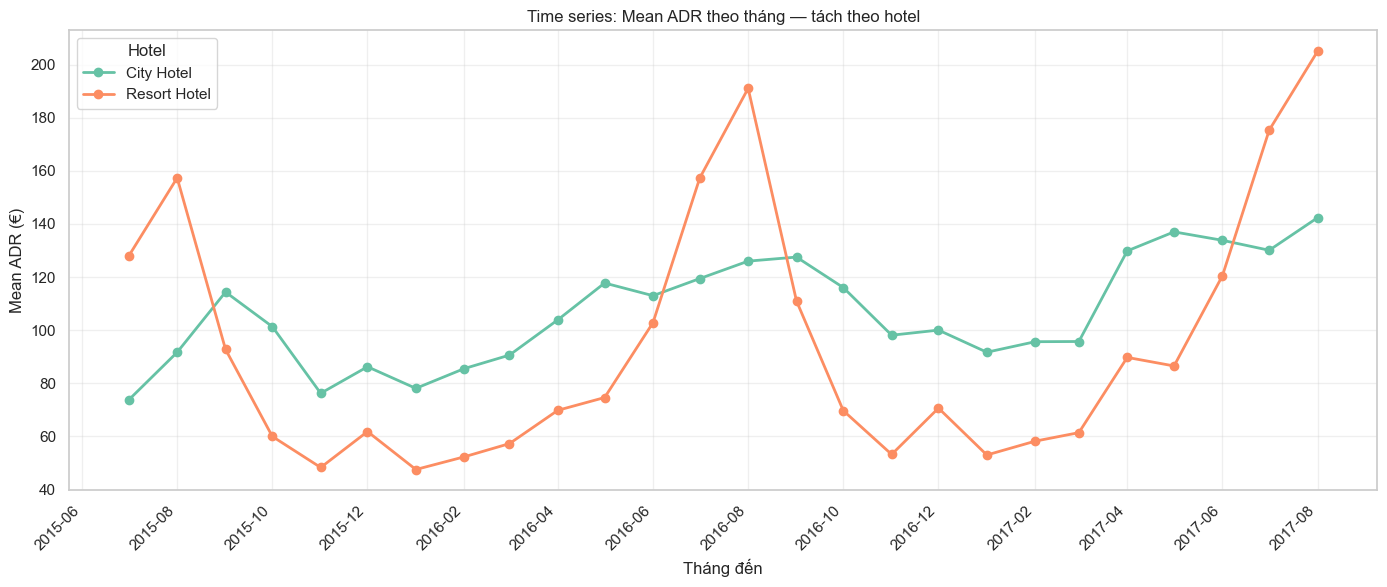

In [13]:
# Time series 4: Mean ADR theo year_month, tách theo hotel
adr_hotel_ts = (
    df_adr.groupby(["year_month", "hotel"], observed=True)["adr"]
    .mean()
    .unstack("hotel")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
for hotel in adr_hotel_ts.columns:
    ax.plot(
        adr_hotel_ts.index,
        adr_hotel_ts[hotel],
        marker="o",
        linewidth=2,
        label=hotel,
    )
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Time series: Mean ADR theo tháng — tách theo hotel")
ax.set_xlabel("Tháng đến")
ax.set_ylabel("Mean ADR (€)")
ax.legend(title="Hotel")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()